# IIC-2433 Minería de Datos UC

- Versiones de librerías, python >= 3.10

- numpy 1.20.3
- sklearn 1.3.1
- DoWhy 0.12
- scipy 1.15.3
- econml 0.15.1

In [4]:
import numpy as np
import pandas as pd
from scipy import stats

import dowhy
from dowhy import CausalModel

from scipy import stats
import statsmodels.api as sm

from itertools import combinations

NOISE_LEVEL = .2
N_SAMPLES = 1000

# Generate the data
a = np.random.randn(N_SAMPLES) 
x = a + NOISE_LEVEL*np.random.randn(N_SAMPLES) 
b = x + NOISE_LEVEL*np.random.randn(N_SAMPLES)
y = a + x + b + NOISE_LEVEL*np.random.randn(N_SAMPLES)
c = y + b + NOISE_LEVEL*np.random.randn(N_SAMPLES)

## Actividad en clase

Haga lo siguiente:

- Modifique el proceso generativo de datos de manera que x sea una variable a intervenir.
- Cree un modelo causal conforme a los datos generados. La variable de salida será y.
- Calcule el estimando relacionado con el efecto causal.
- Calcule el efecto de tratamiento ATE.
- Robustezca el cálculo anterior usando refutación.
- Cuanto termine, me avisa para entregarle una **L (logrado)**.
- Recuerde que cada L es una décima más en la nota de la asignatura.
- Pueden trabajar de a dos.

***Tiene hasta el final de la clase.***


# Solución

In [10]:
# Generate the data
a = np.random.randn(N_SAMPLES)
x = (a + NOISE_LEVEL * np.random.randn(N_SAMPLES) > 0).astype(int)  # booleana {0,1}
b = x + NOISE_LEVEL * np.random.randn(N_SAMPLES)
y = a + x + b + NOISE_LEVEL * np.random.randn(N_SAMPLES)
c = y + b + NOISE_LEVEL * np.random.randn(N_SAMPLES)

# Get combinations
combs = list(combinations([('a', a), ('b', b), ('c', c), ('x', x), ('y', y)], 2))

data = pd.DataFrame(np.vstack([a, b, x, c, y]).T, columns=['A', 'B', 'X', 'C', 'Y'])

data.head()

,A,B,X,C,Y
0,-0.807140,0.398264,0.0,0.042616,-0.451483
1,0.824542,0.979764,1.0,3.246292,2.807569
2,-0.969712,-0.095520,0.0,-1.200550,-1.069783
3,0.958128,0.930263,1.0,4.067375,3.058745
4,0.256268,0.982867,1.0,2.935120,2.015795


In [11]:
nodes = ['A', 'B', 'X', 'C', 'Y']
edges = [
    ('A', 'X'),
    ('X', 'B'),
    ('A', 'Y'),
    ('X', 'Y'),
    ('B', 'Y'),
    ('Y', 'C'),
    ('B', 'C')
]

gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'
    
gml_string += ']'


model = CausalModel(
    data=data,
    treatment='X',
    outcome='Y',
    graph=gml_string
)

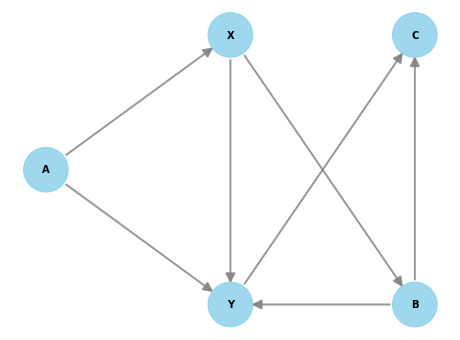

In [12]:
model.view_model()

In [13]:
estimand = model.identify_effect()

print(estimand)

estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.distance_matching',
    target_units='ate',
    method_params={'distance_metric': 'minkowski', 'p': 2})

estimate.value

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|A])
d[X]        
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,A,U) = P(Y|X,A)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [14]:
refutation = model.refute_estimate(
    estimand=estimand, 
    estimate=estimate,
    method_name='data_subset_refuter',
    subset_fraction=0.4)

print(refutation)

Refute: Use a subset of data
Estimated effect:2.5818819715884103
New effect:2.4907166786966384
p value:0.62

